In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

In [3]:
data = pd.read_csv("health_risk.csv")

In [4]:
data

,Age,Sex,BMI,Systolic_BP,Cholesterol,Glucose,Exercise_Min_Week,Smoker,Alcohol,Diet,Health_Risk
0,23,M,18.2,121,186.0,85.0,173.0,1,none,average,0
1,65,M,33.6,134,NaN,NaN,146.0,1,moderate,poor,2
2,58,F,31.1,147,210.0,118.0,220.0,0,none,good,2
3,45,M,27.8,124,180.0,90.0,105.0,0,moderate,average,1
4,44,F,26.8,123,NaN,135.0,158.0,0,moderate,poor,1
...,...,...,...,...,...,...,...,...,...,...,...
5995,31,M,30.9,127,212.0,126.0,231.0,0,high,average,2
5996,70,M,37.1,142,222.0,149.0,214.0,0,high,average,2
5997,78,F,22.2,118,286.0,110.0,135.0,0,moderate,average,2
5998,64,M,34.0,117,174.0,108.0,208.0,0,moderate,poor,2


# Health risk
Zbiór danych służy do analizy czynników wpływających na ryzyko zdrowotne na podstawie cech demograficznych, stylu życia oraz parametrów medycznych. Każdy wiersz reprezentuje jedną osobę.

Opis kolumn:
- Age: wiek osoby, zmienna liczbowa.
- Sex: płeć: M - mężczyzna, F - kobieta, zmienne kategoryczna.
- BMI (Body Mass Index): wskaźnik masy ciała.
- Systolic_BP: ciśnienie skurczowe. Wysokie wartości mogą wskazywać na nadciśnienie.
- Cholesterol: poziom cholesterolu. Podwyższony poziom zwiększa ryzyko chorób serca.
- Glucose: poziom glukozy we krwi. Wysokie wartości mogą sugerować cukrzycę.
- Exercise_Min_Week: liczba minut aktywności fizycznej tygodniowo.
- Smoker: czy osoba pali papierosy: 1 - tak, 0 - nie. Zmienne binarna.
- Alcohol: poziom spożycia alkoholu: none, moderate, high. Zmienne kategoryczna.
- Diet: jakość diety: poor, average, good. Zmienne kategoryczna.
- Health_Risk (zmienna docelowa): poziom ryzyka zdrowotnego: 0 - niskie ryzyko, 1 - umiarkowane, 2 - wysokie. To jest zmienna, którą można przewidywać (klasyfikacja wieloklasowa).

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                6000 non-null   int64  
 1   Sex                6000 non-null   object 
 2   BMI                5826 non-null   float64
 3   Systolic_BP        6000 non-null   int64  
 4   Cholesterol        5829 non-null   float64
 5   Glucose            5816 non-null   float64
 6   Exercise_Min_Week  5828 non-null   float64
 7   Smoker             6000 non-null   int64  
 8   Alcohol            6000 non-null   object 
 9   Diet               5811 non-null   object 
 10  Health_Risk        6000 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 515.8+ KB


In [7]:
data.describe()

,Age,BMI,Systolic_BP,Cholesterol,Glucose,Exercise_Min_Week,Smoker,Health_Risk
count,6000.000000,5826.000000,6000.000000,5829.000000,5816.000000,5828.000000,6000.000000,6000.000000
mean,48.430667,25.964229,125.736667,201.005833,98.197730,141.471517,0.223167,1.340333
std,17.885409,4.960076,17.904052,34.504806,17.921941,86.109873,0.416404,0.661750
min,18.000000,16.000000,85.000000,120.000000,60.000000,0.000000,0.000000,0.000000
25%,33.000000,22.500000,113.000000,178.000000,86.000000,79.000000,0.000000,1.000000
50%,48.000000,25.800000,125.000000,201.000000,98.000000,139.000000,0.000000,1.000000
75%,64.000000,29.300000,138.000000,224.000000,110.000000,200.000000,0.000000,2.000000
max,79.000000,45.000000,189.000000,316.000000,164.000000,529.000000,1.000000,2.000000


In [8]:
data.isnull().sum()

,0
Age,0
Sex,0
BMI,174
Systolic_BP,0
Cholesterol,171
Glucose,184
Exercise_Min_Week,172
Smoker,0
Alcohol,0
Diet,189


In [9]:
(data.isnull().sum() / len(data)) * 100

,0
Age,0.000000
Sex,0.000000
BMI,2.900000
Systolic_BP,0.000000
Cholesterol,2.850000
Glucose,3.066667
Exercise_Min_Week,2.866667
Smoker,0.000000
Alcohol,0.000000
Diet,3.150000


In [11]:
# podział kolumn
num_columns = data.select_dtypes(include=['int64','float64']).columns
cat_columns = data.select_dtypes(include=['object']).columns

# uzupełnianie kolumn liczbowych medianą
for col in num_columns:
  data[col].fillna(data[col].median(),inplace=True)

# uzupełnianie kategorycznych najczęstszą wartością
for col in cat_columns:
  data[col].fillna(data[col].mode()[0], inplace=True)

# sprawdzenie czy zostały braki
print(data.isnull().sum())

Age                  0
Sex                  0
BMI                  0
Systolic_BP          0
Cholesterol          0
Glucose              0
Exercise_Min_Week    0
Smoker               0
Alcohol              0
Diet                 0
Health_Risk          0
dtype: int64


/tmp/ipykernel_663/3007940527.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(),inplace=True)
/tmp/ipykernel_663/3007940527.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [12]:
data.head()

,Age,Sex,BMI,Systolic_BP,Cholesterol,Glucose,Exercise_Min_Week,Smoker,Alcohol,Diet,Health_Risk
0,23,M,18.2,121,186.0,85.0,173.0,1,none,average,0
1,65,M,33.6,134,201.0,98.0,146.0,1,moderate,poor,2
2,58,F,31.1,147,210.0,118.0,220.0,0,none,good,2
3,45,M,27.8,124,180.0,90.0,105.0,0,moderate,average,1
4,44,F,26.8,123,201.0,135.0,158.0,0,moderate,poor,1


In [13]:
# liczba obserwacji w każdej klasie
class_counts = data["Health_Risk"].value_counts().sort_index()
print("Liczebność klas:")
print(class_counts)

Liczebność klas:
Health_Risk
0     640
1    2678
2    2682
Name: count, dtype: int64


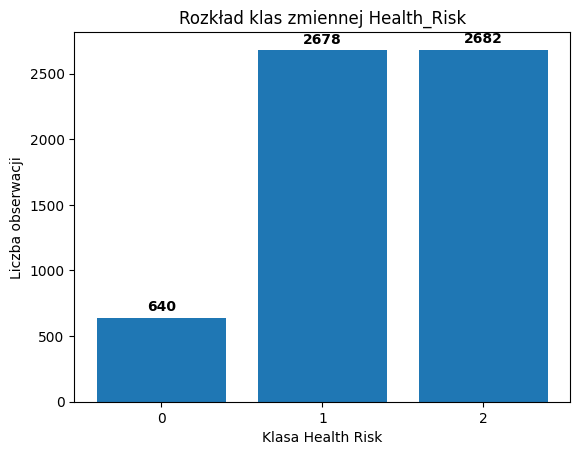

In [14]:
plt.figure()
plt.bar(class_counts.index.astype(str),class_counts.values)
# Dodanie wartości nad słupkami
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.xlabel("Klasa Health Risk")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład klas zmiennej Health_Risk")
plt.show()

In [16]:
X = data.drop('Health_Risk', axis=1)
y = data['Health_Risk']

In [17]:
# One-hot encoding dla zmiennych kategorycznych
category_columns = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=category_columns,drop_first=True)

In [18]:
X_encoded

,Age,BMI,Systolic_BP,Cholesterol,Glucose,Exercise_Min_Week,Smoker,Sex_M,Alcohol_moderate,Alcohol_none,Diet_good,Diet_poor
0,23,18.2,121,186.0,85.0,173.0,1,True,False,True,False,False
1,65,33.6,134,201.0,98.0,146.0,1,True,True,False,False,True
2,58,31.1,147,210.0,118.0,220.0,0,False,False,True,True,False
3,45,27.8,124,180.0,90.0,105.0,0,True,True,False,False,False
4,44,26.8,123,201.0,135.0,158.0,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,31,30.9,127,212.0,126.0,231.0,0,True,False,False,False,False
5996,70,37.1,142,222.0,149.0,214.0,0,True,False,False,False,False
5997,78,22.2,118,286.0,110.0,135.0,0,False,True,False,False,False
5998,64,34.0,117,174.0,108.0,208.0,0,True,True,False,False,True


In [19]:
# standaryzacja cech numerycznych
numeric_columns = X.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
X_encoded[numeric_columns] = scaler.fit_transform(X_encoded[numeric_columns])


In [20]:
X_encoded

,Age,BMI,Systolic_BP,Cholesterol,Glucose,Exercise_Min_Week,Smoker,Sex_M,Alcohol_moderate,Alcohol_none,Diet_good,Diet_poor
0,-1.421985,-1.587685,-0.264580,-0.441257,-0.747678,0.372369,1.865732,True,False,True,False,False
1,0.926493,1.563349,0.461573,-0.000167,-0.010863,0.054199,1.865732,True,True,False,False,True
2,0.535080,1.051818,1.187726,0.264488,1.122698,0.926219,-0.535983,False,False,True,True,False
3,-0.191830,0.376596,-0.097007,-0.617693,-0.464288,-0.428948,-0.535983,True,True,False,False,False
4,-0.247746,0.171984,-0.152865,-0.000167,2.086225,0.195608,-0.535983,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,-0.974656,1.010895,0.070567,0.323300,1.576122,1.055844,-0.535983,True,False,False,False,False
5996,1.206074,2.279494,0.908436,0.617360,2.879717,0.855515,-0.535983,True,False,False,False,False
5997,1.653404,-0.769234,-0.432154,2.499345,0.669273,-0.075426,-0.535983,False,True,False,False,False
5998,0.870577,1.645195,-0.488012,-0.794129,0.555917,0.784811,-0.535983,True,True,False,False,True


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

In [22]:
print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)
print("Proporcje klas w zbiorze treningowym:\n", y_train.value_counts(normalize=True))
print("Proporcje klas w zbiorze testowym:\n", y_test.value_counts(normalize=True))

Rozmiar zbioru treningowego: (4200, 12)
Rozmiar zbioru testowego: (1800, 12)
Proporcje klas w zbiorze treningowym:
 Health_Risk
2    0.446905
1    0.446429
0    0.106667
Name: proportion, dtype: float64
Proporcje klas w zbiorze testowym:
 Health_Risk
2    0.447222
1    0.446111
0    0.106667
Name: proportion, dtype: float64


Porównanie dwóch modeli klasyfikacyjnych: regresja logistyczna i drzewo decyzyjne

In [24]:
# regresja logistyczna
logreg = LogisticRegression()
logreg.fit(X_train,y_train)
y_pred_logreg = logreg.predict(X_test)

# drzewo decyzyjne
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)
y_pred_tree = tree.predict(X_test)

print("Regresja logistyczna:")
print("Dokładność:",accuracy_score(y_test,y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

print("\nDrzewo decyzyjne:")
print("Dokładność:",accuracy_score(y_test,y_pred_tree))
print(classification_report(y_test,y_pred_tree))

Regresja logistyczna:
Dokładność: 0.7211111111111111
              precision    recall  f1-score   support

           0       0.63      0.42      0.50       192
           1       0.67      0.73      0.70       803
           2       0.79      0.78      0.78       805

    accuracy                           0.72      1800
   macro avg       0.70      0.64      0.66      1800
weighted avg       0.72      0.72      0.72      1800


Drzewo decyzyjne:
Dokładność: 0.5933333333333334
              precision    recall  f1-score   support

           0       0.39      0.41      0.40       192
           1       0.57      0.57      0.57       803
           2       0.67      0.66      0.67       805

    accuracy                           0.59      1800
   macro avg       0.54      0.55      0.54      1800
weighted avg       0.60      0.59      0.59      1800



Ocena jakości modeli w klasyfikacji wieloklasowej:
accuracy,
F1-score w wersji macro lub weighted,
macierz pomyłek

Regresja logistyczna
Dokładność: 0.7211111111111111
F1-score macro: 0.6631300397069119
F1-score weight: 0.7175702684734766
Macierz pomyłek:
 [[ 80 109   3]
 [ 46 589 168]
 [  0 176 629]]


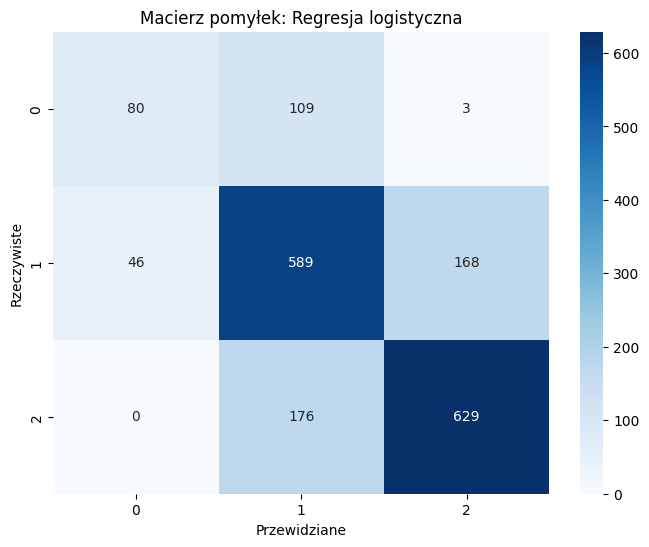

Drzewo decyzyjne
Dokładność: 0.5933333333333334
F1-score macro: 0.5446721233795162
F1-score weight: 0.5942610137586679
Macierz pomyłek:
 [[ 79  95  18]
 [108 455 240]
 [ 17 254 534]]


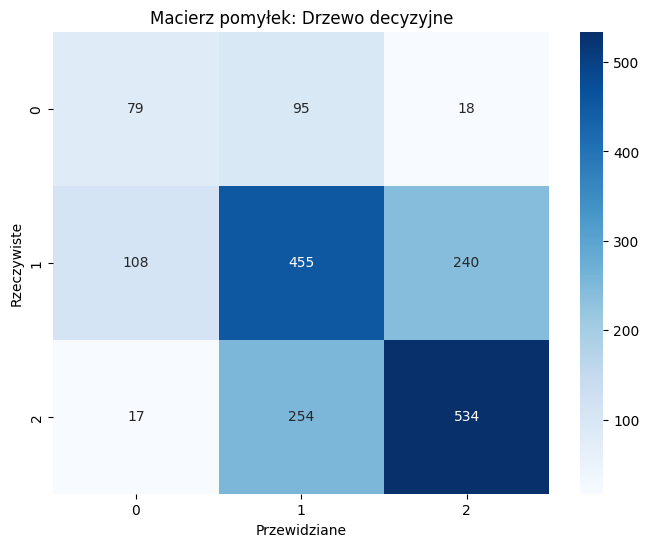

In [25]:
# ocena jakości modeli

models = { "Regresja logistyczna":y_pred_logreg, "Drzewo decyzyjne": y_pred_tree}

for name, y_pred in models.items():
  print(name)
  print("Dokładność:",accuracy_score(y_test,y_pred))
  print("F1-score macro:",f1_score(y_test,y_pred,average='macro'))
  print("F1-score weight:",f1_score(y_test,y_pred,average='weighted'))

  cm = confusion_matrix(y_test,y_pred)
  print("Macierz pomyłek:\n",cm)

  plt.figure(figsize=(8,6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.title(f"Macierz pomyłek: {name}")
  plt.xlabel("Przewidziane")
  plt.ylabel("Rzeczywiste")
  plt.show()

In [27]:
# Wyniki
# Regresja logistyczna
# Dokładność: 0.721, model poprawnie przewidział ~72% wszystkich obserwacji.
# F1-score macro: 0.663, średnia skuteczność dla wszystkich klas jest niższa, co sugeruje, że model gorzej radzi sobie z mniej licznymi klasami.
# F1-score weighted: 0.718, uwzględnia liczbę obserwacji w każdej klasie, wynik zbliżony do accuracy, bo klasy 1 i 2 są dominujące.

# Klasa 0 jest często mylona z klasą 1 (109 razy). Klasa 1 i 2 mają lepszą przewidywalność, ale klasa 1 jest mylona z klasą 2 (168 razy).
# To tłumaczy, dlaczego F1 macro < F1 weighted - mała klasa 0 obniża średnią prostą.

In [28]:
# Drzewo decyzyjne
# Dokładność: 0.601, tylko ~60% poprawnych przewidywań, czyli gorzej niż regresja logistyczna.
# F1-score macro: 0.548, średnia dla wszystkich klas niska, wskazuje na problemy z mniejszymi klasami.
# F1-score weighted: 0.601, również niska, bo model nie radzi sobie dobrze nawet z dużymi klasami.

# Bardziej chaotyczne przewidywania niż w regresji logistycznej. Klasa 1 jest mylona z klasą 2 224 razy, dużo więcej niż w regresji logistycznej.
# Klasa 0 jest mylona zarówno z 1 (95) jak i z 2 (22).
# Wynik F1 macro i weighted jest nisko, bo drzewo decyzyjne nadmiernie dopasowało się do większych klas i mniej radzi sobie z małą klasą.

In [29]:
# Podsumowanie: Regresja logistyczna radzi sobie lepiej z tym zbiorem danych, ma wyższą dokładność i F1-score weighted.
# Drzewo decyzyjne ma większe problemy z przewidywaniem klasy 1 i 0, co widać w macierzy pomyłek.
# Różnica między F1 macro a weighted pokazuje nierównomierne rozłożenie klas, mniejsza klasa 0 obniża F1 macro, ale weighted jest wyższe, bo model dobrze
# przewiduje dominujące klasy 1 i 2.

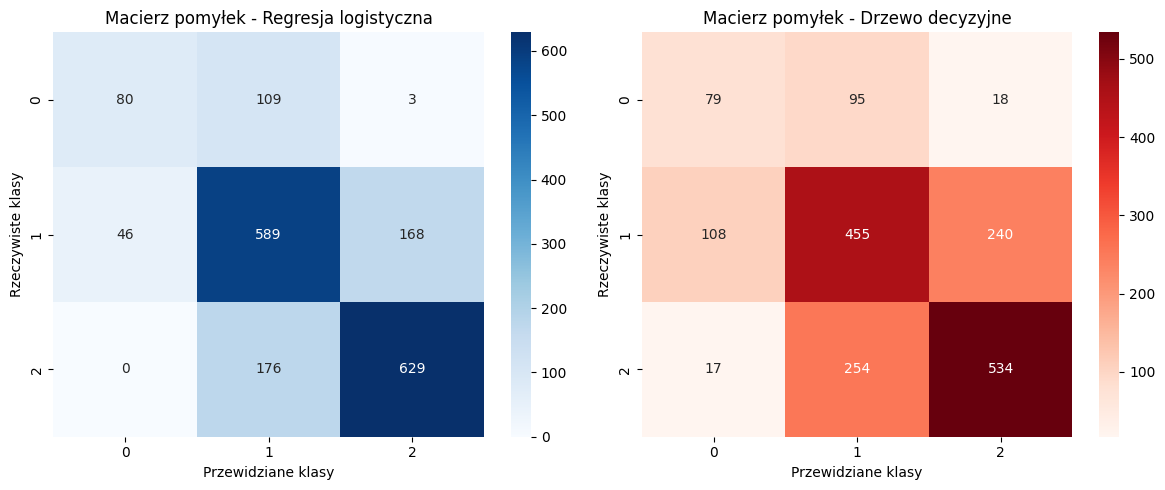

In [30]:
from sklearn.metrics import confusion_matrix

# Macierze pomyłek
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regresja logistyczna
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Macierz pomyłek - Regresja logistyczna")
axes[0].set_xlabel("Przewidziane klasy")
axes[0].set_ylabel("Rzeczywiste klasy")

# Drzewo decyzyjne
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title("Macierz pomyłek - Drzewo decyzyjne")
axes[1].set_xlabel("Przewidziane klasy")
axes[1].set_ylabel("Rzeczywiste klasy")

plt.tight_layout()
plt.show()

Zastosowanie podejścia class_weight='balanced' w regresji logistycznej


In [31]:
# regresja logistyczna z wagą 'balanced'
logreg_balanced = LogisticRegression(class_weight='balanced')
logreg_balanced.fit(X_train, y_train)
y_pred_logreg_balanced = logreg_balanced.predict(X_test)

# prównanie wyników
models_logreg_balanced = {"Regresja logistyczna standardowa":y_pred_logreg, "Regresja logistyczna 'balanced'": y_pred_logreg_balanced}

for name, y_pred in models_logreg_balanced.items():
  print(name)
  print("Dokładność:",accuracy_score(y_test,y_pred))
  print("F1-score macro:", f1_score(y_test, y_pred, average='macro'))
  print("F1-score weighted:", f1_score(y_test, y_pred,average='weighted'))
  cm = confusion_matrix(y_test, y_pred)
  print("Macierz pomyłek:\n", cm)

Regresja logistyczna standardowa
Dokładność: 0.7211111111111111
F1-score macro: 0.6631300397069119
F1-score weighted: 0.7175702684734766
Macierz pomyłek:
 [[ 80 109   3]
 [ 46 589 168]
 [  0 176 629]]
Regresja logistyczna 'balanced'
Dokładność: 0.6916666666666667
F1-score macro: 0.6625515665785985
F1-score weighted: 0.694001577769686
Macierz pomyłek:
 [[144  45   3]
 [163 472 168]
 [  6 170 629]]


## Obserwacje:
Dokładność spadła z 0.721 do 0.692.

F1-score weighted spadło z 0.718 do 0.694.
Weighted bierze pod uwagę liczbę obserwacji w klasach. Spadło, bo model przewiduje mniej dokładnie dużą klasę (klasa 1), która jest liczniejsza.

## Analiza macierzy pomyłek
 Standardowa: klasa 0 jest często mylona z klasą 1 (109 razy). Klasy 1 i 2 są przewidywane dobrze, bo są liczne.
 Balanced: klasa 0 jest znacznie lepiej przewidywana (144 prawidłowe zamiast 80). Klasa 1 jest gorzej przewidywana (472 zamiast 589), bo model teraz bardziej zwraca uwagę na małą klasę.
 Klasa 2 praktycznie bez zmian.

## Wnioski:
 Uwzględnienie wag klas balanced: poprawia przewidywania mniejszych klas (klasa 0). Sprawdza się, jeśli mała klasa jest krytyczna.
 Koszt: spada dokładność ogólna i F1 weighted, bo model mniej precyzyjnie przewiduje duże klasy.
 Interpretacja: standardowy model faworyzuje duże klasy, ignorując małą klasę.

In [ ]:
#Model	                            Accuracy	F1-score macro	F1-score weighted
# Regresja logistyczna standardowa	0.721	      0.663	          0.718
# Regresja logistyczna balanced	    0.692	      0.663	          0.694
# Drzewo decyzyjne	                0.601	      0.548	          0.601

## Wnioski:
* Regresja logistyczna standardowa osiąga najwyższą dokładność i F1 weighted.

* Balanced poprawia przewidywania małej klasy (0), ale spada accuracy i F1 weighted.
* Drzewo decyzyjne wypada słabiej we wszystkich metrykach – zarówno ogólnej, jak i dla małych klas.

## Wybór najlepszego modelu: Regresja logistyczna standardowa
* ma najwyższą ogólną dokładność i F1 weighted, dobrze przewiduje klasy dominujące, które stanowią większość obserwacji.
* Jeśli priorytetem byłaby poprawa przewidywań dla klasy 0, warto użyć wersji balanced.